<a href="https://colab.research.google.com/github/S8H1L9581/ML-LAB-CH.SC.U4CSE24039/blob/main/7_6_Exercise2_Classification_Tree_Weather.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 7.6 Exercise 2 — Classification Tree: Weather Deciding "Go Out" vs. "Stay In"

**Scenario (from the exercise):** What you do after work depends on the weather.
- If it is **sunny**, you might picnic with a friend, grab a drink with a colleague, or run errands → classified as **"go out."**
- If it is **raining**, you might stay home and watch a movie → classified as **"stay in."**

This is a simple classification problem where `weather` is the key driver of a binary outcome (`go_out` vs. `stay_in`), and a decision tree is a natural way to model it.

## Dataset

This notebook uses a **synthetically generated dataset** built to mirror the scenario: entries with `sunny` weather map (mostly) to `go_out`, and entries with `rain` map (mostly) to `stay_in`, with a bit of realistic noise (e.g., someone sunny-day who still stays in) and an extra `temperature` feature so the tree has more than one variable to split on — similar in spirit to the classic "Play Tennis" weather dataset used to teach decision trees.

If you'd like a well-known real-world dataset with the same flavor (weather conditions → decision), see:
- **UCI "Play Tennis" weather dataset (Quinlan's classic example):** https://www.kaggle.com/datasets/fredericobreno/play-tennis
- **Kaggle "Weather Dataset" for classification:** https://www.kaggle.com/datasets/muthuj7/weather-dataset

We proceed with the synthetic dataset so this notebook runs end-to-end without needing an external download.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

np.random.seed(7)
%matplotlib inline

## 2. Generate the Synthetic Dataset

In [2]:
n_samples = 600

weather = np.random.choice(['sunny', 'rainy'], size=n_samples, p=[0.55, 0.45])
temperature = np.where(
    weather == 'sunny',
    np.random.normal(28, 4, n_samples),   # warmer on sunny days
    np.random.normal(18, 4, n_samples)    # cooler on rainy days
).round(1)

# Decision rule with noise:
# sunny -> mostly go_out (higher chance if temp is pleasant, not too hot)
# rainy -> mostly stay_in
go_out_prob = np.where(
    weather == 'sunny',
    np.clip(0.85 - np.abs(temperature - 26) * 0.01, 0.55, 0.95),
    np.clip(0.15 + np.maximum(0, temperature - 15) * 0.01, 0.05, 0.35)
)

decision = np.random.binomial(1, go_out_prob)
decision_label = np.where(decision == 1, 'go_out', 'stay_in')

df = pd.DataFrame({
    'weather': weather,
    'temperature': temperature,
    'decision': decision_label
})

print(df.shape)
df.head(10)

(600, 3)


,weather,temperature,decision
0,sunny,25.4,go_out
1,rainy,13.2,stay_in
2,sunny,35.6,go_out
3,rainy,16.1,stay_in
4,rainy,13.5,stay_in
5,sunny,29.2,go_out
6,sunny,28.0,go_out
7,sunny,26.6,stay_in
8,sunny,22.6,go_out
9,sunny,24.2,go_out


In [3]:
print(df.groupby('weather')['decision'].value_counts(normalize=True).round(2))

weather  decision
rainy    stay_in     0.83
         go_out      0.17
sunny    go_out      0.83
         stay_in     0.17
Name: proportion, dtype: float64


## 3. Encode Categorical Feature

Decision trees in scikit-learn need numeric input, so we encode `weather` as 0/1.

In [4]:
le_weather = LabelEncoder()
df['weather_enc'] = le_weather.fit_transform(df['weather'])   # rainy=0, sunny=1 (alphabetical)
print(dict(zip(le_weather.classes_, le_weather.transform(le_weather.classes_))))

le_decision = LabelEncoder()
df['decision_enc'] = le_decision.fit_transform(df['decision'])  # go_out=0, stay_in=1 (alphabetical)
print(dict(zip(le_decision.classes_, le_decision.transform(le_decision.classes_))))

{'rainy': np.int64(0), 'sunny': np.int64(1)}
{'go_out': np.int64(0), 'stay_in': np.int64(1)}


## 4. Train/Test Split

In [5]:
X = df[['weather_enc', 'temperature']]
y = df['decision_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7, stratify=y
)
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

Training samples: 450, Testing samples: 150


## 5. Build the Classification Tree

In [6]:
clf = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=7)
clf.fit(X_train, y_train)

feature_names = ['weather', 'temperature']
root_feature_index = clf.tree_.feature[0]
print(f"Root node splits on: '{feature_names[root_feature_index]}'")

Root node splits on: 'weather'


This confirms `weather` is the dominant first split — matching the scenario where the outcome ("go out" vs. "stay in") is primarily determined by whether it's sunny or rainy.

## 6. Visualize the Tree

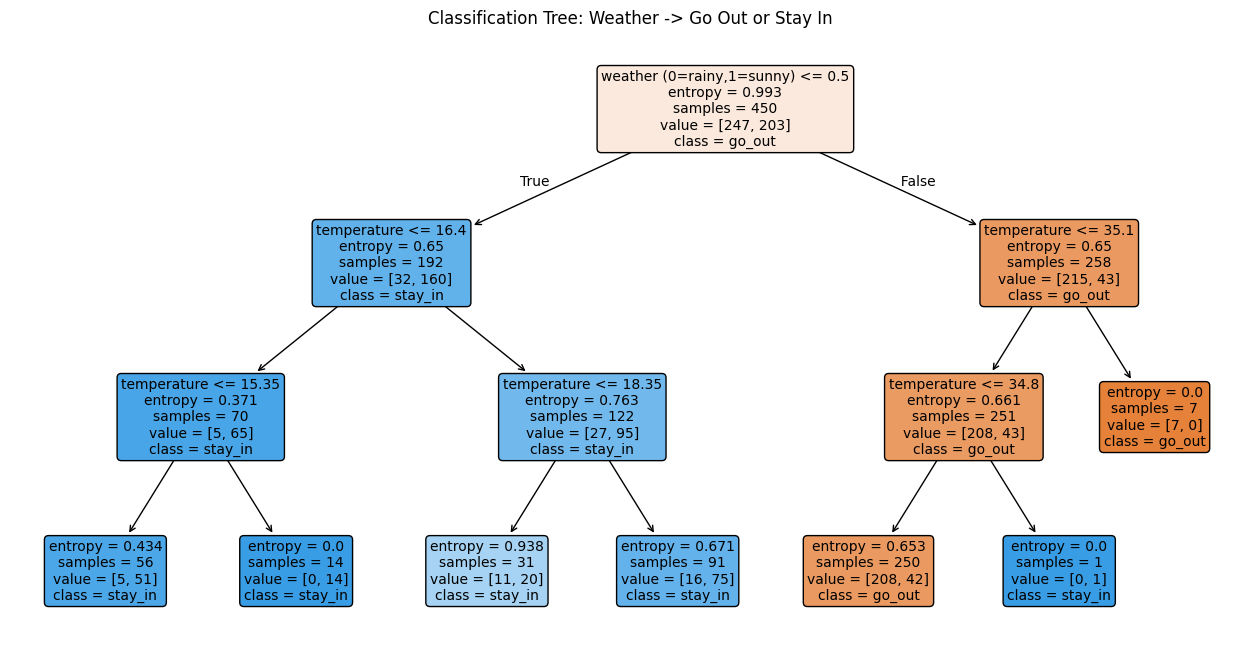

In [7]:
plt.figure(figsize=(16, 8))
plot_tree(
    clf,
    feature_names=['weather (0=rainy,1=sunny)', 'temperature'],
    class_names=le_decision.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Classification Tree: Weather -> Go Out or Stay In')
plt.show()

## 7. Evaluate the Model

In [8]:
y_pred = clf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le_decision.classes_))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Accuracy: 82.00%

Classification Report:
              precision    recall  f1-score   support

      go_out       0.81      0.88      0.84        82
     stay_in       0.84      0.75      0.79        68

    accuracy                           0.82       150
   macro avg       0.82      0.81      0.82       150
weighted avg       0.82      0.82      0.82       150

Confusion Matrix:
[[72 10]
 [17 51]]


## 8. Try a Prediction

Let's classify a new day: **sunny, 24°C**.

In [9]:
new_day = pd.DataFrame({
    'weather_enc': le_weather.transform(['sunny']),
    'temperature': [24]
})
pred = clf.predict(new_day)
print(f"Predicted decision: {le_decision.inverse_transform(pred)[0]}")

Predicted decision: go_out


## Conclusion

- The tree's **root node splits on `weather`**, confirming it is the primary driver of the "go out" vs. "stay in" decision, exactly as described in the exercise.
- `temperature` acts as a secondary/refining feature within each weather branch (e.g., very hot sunny days lower the chance of going out slightly).
- This illustrates how a classification tree can encode simple, human-interpretable "if sunny → likely go out; if rainy → likely stay in" logic directly from data.